# 05 — Scores, modes, and monetization

Three descriptive questions the earlier notebooks raised but did not answer: how scores distribute in each of the two game modes, how player volume falls off across the level ladder, and when in a player's life money appears.

**Inputs:** `post_score_distribution.csv` (312 rows), `monetization_events.csv` (1,939 rows), `day_0.csv` — all from `03_event_pulls.ipynb`.
**Produces:** no files.

The score work uses every player, since it asks about game mechanics and mechanics have no install clock. The monetization work uses the cohort only, because "days since install" is undefined for players who installed before the window opened. Two different questions, two different populations, deliberately.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
ps = pd.read_csv('post_score_distribution.csv')

print(ps.shape)
print(ps.dtypes)
ps.head()

(312, 4)
level       int64
score       int64
mode       object
n_posts     int64
dtype: object


,level,score,mode,n_posts
0,0,0,quickplay,56174
1,0,1,quickplay,52321
2,0,2,quickplay,43179
3,0,3,quickplay,29123
4,0,4,quickplay,15832


## Score distribution by mode

Level 0 is not a level. It is quickplay's scoring bucket and doubles as the mode flag — the deduction behind that is documented in notebook 03. Splitting on it separates the two modes.

The two modes have different score shapes, and the level-mode side needs unpacking before it can be read: it pools thirty levels, and the cells below show they do not share a score range. Note the log scale on the left panel — quickplay's decay is steep enough that a linear axis would flatten everything past score 6 into the floor.

In [3]:
quickplay = ps[ps['level'] == 0]
quickplay

,level,score,mode,n_posts
0,0,0,quickplay,56174
1,0,1,quickplay,52321
2,0,2,quickplay,43179
3,0,3,quickplay,29123
4,0,4,quickplay,15832
5,0,5,quickplay,6634
6,0,6,quickplay,2281
7,0,7,quickplay,638
8,0,8,quickplay,142
9,0,9,quickplay,34


In [4]:
level_mode = ps[ps['level'] > 0]

level_mode_per_score = level_mode.groupby('score')['n_posts'].sum()
level_mode_per_score

,n_posts
score,
0,5578
1,3859
2,3217
3,2615
4,1896
5,1852
6,1807
7,1675
8,1738


### Is the ceiling the same on every level?

The distribution above pools thirty levels. That is only a fair summary if they share a score range — if levels differ in score range, the pooled series is a mixture and the pile-up at 21 might belong to a subset of levels rather than to the game as a whole.

The row count is what raises the question: 296 rows across 30 levels is roughly ten distinct scores per level, where a uniform 0–21 range would allow up to 660. The cells below check each level's actual score range, where the posts at score 21 sit, and whether posts concentrate at each level's own maximum.

In [5]:
by_level = level_mode.groupby('level').agg(
    min_score=('score', 'min'),
    max_score=('score', 'max'),
    n_distinct_scores=('score', 'nunique'),
    posts=('n_posts', 'sum')
)

at_21 = (level_mode[level_mode['score'] == 21]
         .set_index('level')['n_posts']
         .reindex(by_level.index, fill_value=0))

by_level['posts_at_21'] = at_21
by_level['share_at_21'] = (by_level['posts_at_21'] / by_level['posts']).round(3)
display(by_level)

,min_score,max_score,n_distinct_scores,posts,posts_at_21,share_at_21
level,,,,,,
1,0,21,19,3947,3415,0.865
2,0,18,15,3340,0,0.000
3,0,10,11,2969,0,0.000
4,0,14,10,2641,0,0.000
5,0,12,9,2064,0,0.000
6,0,12,7,1678,0,0.000
7,0,5,6,1407,0,0.000
8,0,10,7,1205,0,0.000
9,0,4,5,987,0,0.000


In [6]:
max_rows = level_mode.merge(by_level[['max_score']], left_on='level', right_index=True)
at_max = max_rows[max_rows['score'] == max_rows['max_score']].groupby('level')['n_posts'].sum()

by_level['posts_at_max'] = at_max.reindex(by_level.index, fill_value=0)
by_level['share_at_max'] = (by_level['posts_at_max'] / by_level['posts']).round(3)
display(by_level[['max_score', 'posts', 'posts_at_max', 'share_at_max']])

,max_score,posts,posts_at_max,share_at_max
level,,,,
1,21,3947,3415,0.865
2,18,3340,1,0.000
3,10,2969,6,0.002
4,14,2641,1,0.000
5,12,2064,1,0.000
6,12,1678,1,0.001
7,5,1407,1,0.001
8,10,1205,1,0.001
9,4,987,8,0.008


### Level 1 accounts for the entire ceiling

Score 21 occurs on level 1 and nowhere else, where it holds 86.5% of the level's posts. No other level exceeds 18, and no other level concentrates more than 3.8% of its posts at its own maximum — so this is not a general "posts pile at the top" pattern. It is one level behaving unlike the other twenty-nine.

That makes the pooled distribution a mixture of thirty different supports, so the chart below plots level 1 separately. Reading the pooled series alone would suggest a game-wide score ceiling that the per-level data does not support.

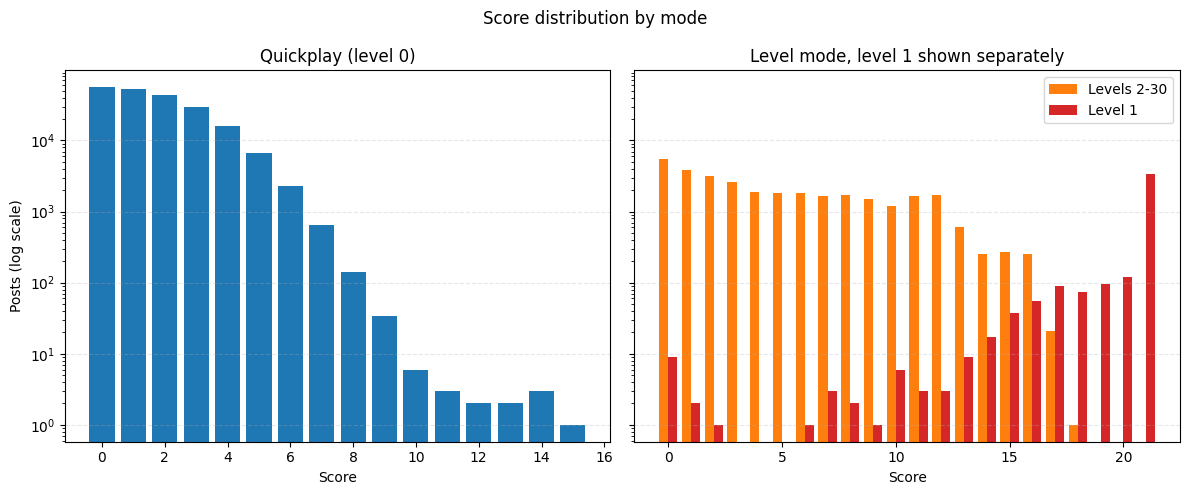

In [7]:
scores = list(range(0, 22))
l1 = level_mode[level_mode['level'] == 1].groupby('score')['n_posts'].sum().reindex(scores, fill_value=0)
rest = level_mode[level_mode['level'] > 1].groupby('score')['n_posts'].sum().reindex(scores, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

axes[0].bar(quickplay['score'], quickplay['n_posts'], color='tab:blue')
axes[0].set_yscale('log')
axes[0].set_title('Quickplay (level 0)')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Posts (log scale)')
axes[0].grid(alpha=0.3, linestyle='--', axis='y')

axes[1].bar([s - 0.2 for s in scores], rest.values, width=0.4, color='tab:orange', label='Levels 2-30')
axes[1].bar([s + 0.2 for s in scores], l1.values, width=0.4, color='tab:red', label='Level 1')
axes[1].set_title('Level mode, level 1 shown separately')
axes[1].set_xlabel('Score')
axes[1].legend()
axes[1].grid(alpha=0.3, linestyle='--', axis='y')

fig.suptitle('Score distribution by mode')
plt.tight_layout()
plt.show()

## Progression through the level ladder

Post volume by level, as a proxy for how many players reached each one. The y-axis starts at zero deliberately — the drop at the end is a claim about magnitude, and a truncated axis would inflate it.

One caveat on the proxy: post volume equals players only if posts-per-player is roughly constant across levels. This data has no user counts, so that cannot be checked here — and level 1, with 86% of its posts at a single score, is visibly not behaving like the others. Treat the level-1 value with caution; the shape from level 2 onward is the more reliable part.

In [8]:
level_mode_per_level = level_mode.groupby('level')['n_posts'].sum()
level_mode_per_level

,n_posts
level,
1,3947
2,3340
3,2969
4,2641
5,2064
6,1678
7,1407
8,1205
9,987


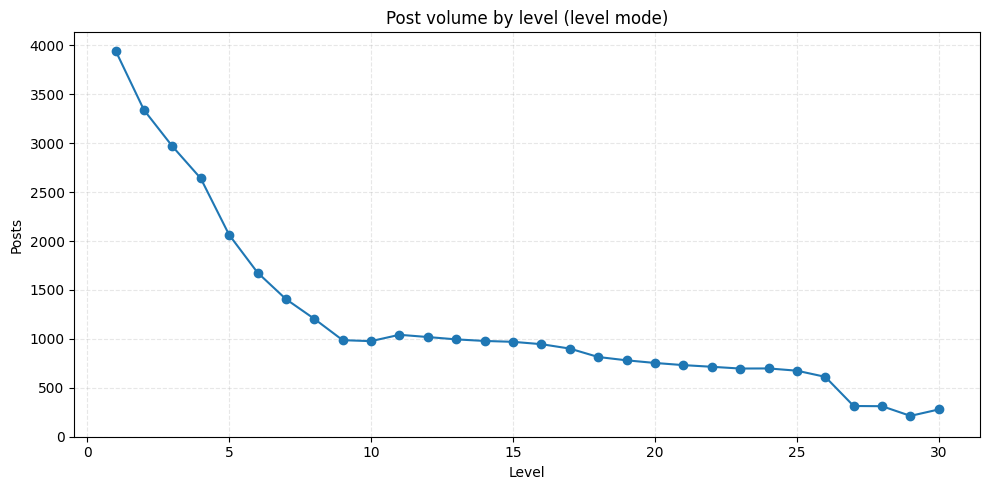

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(level_mode_per_level.index, level_mode_per_level.values, marker='o')
ax.set_xlabel('Level')
ax.set_ylabel('Posts')
ax.set_ylim(bottom=0)
ax.set_title('Post volume by level (level mode)')
ax.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

## Monetization

Two very different behaviours share this file. Rewarded ad views number 1,912 across 354 players; deliberate purchases number 27, made by 27 distinct players, with no repeat buyers anywhere in 114 days.

The question is *when* a purchase happens in a player's life, which needs an install date — so the purchases are joined to `day_0`. That join is what reduces 27 buyers to 17: the other ten installed before the window opened and have no measurable day zero. The gate cell makes the resulting denominator explicit rather than leaving it to be inferred.

Everything in this section is descriptive. At n=27 no rate, comparison, or trend would survive scrutiny, and none is offered.

In [10]:
me = pd.read_csv('monetization_events.csv', parse_dates = ['event_date'])

print(me.shape)
print(me.dtypes)
me.head()

(1939, 10)
user_pseudo_id             object
event_date         datetime64[ns]
event_timestamp             int64
event_name                 object
product_id                 object
price                     float64
currency                   object
validated                 float64
type                       object
value                     float64
dtype: object


,user_pseudo_id,event_date,event_timestamp,event_name,product_id,price,currency,validated,type,value
0,00AE0CA4117376AE083FD6AEA744CE88,2018-09-02,1535943983925000,ad_reward,NaN,NaN,NaN,NaN,Steps,5.0
1,00AE0CA4117376AE083FD6AEA744CE88,2018-09-02,1535944080985000,ad_reward,NaN,NaN,NaN,NaN,Steps,5.0
2,014EE05605C94D797CA52C355638C967,2018-08-13,1534198373295000,ad_reward,NaN,NaN,NaN,NaN,Steps,2.0
3,014EE05605C94D797CA52C355638C967,2018-08-13,1534198445681031,ad_reward,NaN,NaN,NaN,NaN,Steps,2.0
4,014EE05605C94D797CA52C355638C967,2018-08-13,1534198451217008,ad_reward,NaN,NaN,NaN,NaN,Steps,2.0


In [11]:
display(me['event_name'].value_counts())

me_purchases = me[me['event_name'] == 'in_app_purchase']
print(me_purchases.shape)
display(me_purchases)

,count
event_name,
ad_reward,1912
in_app_purchase,27


(27, 10)


,user_pseudo_id,event_date,event_timestamp,event_name,product_id,price,currency,validated,type,value
14,032918145D0FE92E31B0D5194DB1A4C3,2018-06-28,1530224360476000,in_app_purchase,remove_ads,0.99,USD,NaN,NaN,990000.0
206,1764DE126468943A92164D6E0063E36B,2018-06-28,1530235275743000,in_app_purchase,remove_ads,0.99,USD,1.0,NaN,990000.0
211,18CB1F3F03C919DE0D79B07F291F7DB2,2018-06-26,1530061771028000,in_app_purchase,extra_steps_pack_3,4.99,USD,1.0,NaN,4990000.0
241,210C3692734E251EEF4E952BC57DD998,2018-08-01,1533160799125000,in_app_purchase,remove_ads,3.69,AED,1.0,NaN,3690000.0
253,248A372CD2ED3B5D62866E77AC6D661B,2018-09-25,1537944489272000,in_app_purchase,remove_ads,0.99,USD,1.0,NaN,990000.0
260,27E0D1C7B0A13B685AE0F2AA89B8B1A0,2018-09-20,1537441910746000,in_app_purchase,remove_ads,120.00,JPY,1.0,NaN,120000000.0
279,2E03DB1924573F3131EEC916E5444F56,2018-06-21,1529574302719000,in_app_purchase,remove_ads,0.99,USD,1.0,NaN,990000.0
562,4032085C28047CF8EA19354C6DD88A82,2018-07-31,1533030134788000,in_app_purchase,remove_ads,30.00,TWD,1.0,NaN,30000000.0
779,4C038479B275A5F024A8A7604F92BF38,2018-08-07,1533648191159000,in_app_purchase,remove_ads,0.99,USD,NaN,NaN,990000.0
831,4ECE982F87221BF7A2C3642A15329244,2018-09-12,1536786556604000,in_app_purchase,remove_ads,0.99,USD,NaN,NaN,990000.0


In [12]:
day_0 = pd.read_csv('day_0.csv', parse_dates = ['day_0'])

print(day_0.shape)
print(day_0.dtypes)
day_0.head()

(4319, 2)
user_pseudo_id            object
day_0             datetime64[ns]
dtype: object


,user_pseudo_id,day_0
0,1814A35D096333518F94B02DDFE3BFEC,2018-06-15
1,4F8458200DBF0AD3A4B095CA35EEA47C,2018-06-15
2,6B41795D5E5B7339E007330941C9E201,2018-06-15
3,0FB42D5FFB79A9DE147873753BF7A664,2018-07-15
4,61C77C8D9E7F92524289DA7E9D4786BF,2018-07-15


In [13]:
days_to_purchase = pd.merge(me_purchases, day_0, on = 'user_pseudo_id', how = 'left')
display(days_to_purchase)

days_to_purchase['days_to_purchase'] = (days_to_purchase['event_date'] - days_to_purchase['day_0']).dt.days
print()
display(days_to_purchase.sort_values('days_to_purchase', ascending = False))

,user_pseudo_id,event_date,event_timestamp,event_name,product_id,price,currency,validated,type,value,day_0
0,032918145D0FE92E31B0D5194DB1A4C3,2018-06-28,1530224360476000,in_app_purchase,remove_ads,0.99,USD,NaN,NaN,990000.0,NaT
1,1764DE126468943A92164D6E0063E36B,2018-06-28,1530235275743000,in_app_purchase,remove_ads,0.99,USD,1.0,NaN,990000.0,NaT
2,18CB1F3F03C919DE0D79B07F291F7DB2,2018-06-26,1530061771028000,in_app_purchase,extra_steps_pack_3,4.99,USD,1.0,NaN,4990000.0,NaT
3,210C3692734E251EEF4E952BC57DD998,2018-08-01,1533160799125000,in_app_purchase,remove_ads,3.69,AED,1.0,NaN,3690000.0,2018-08-01
4,248A372CD2ED3B5D62866E77AC6D661B,2018-09-25,1537944489272000,in_app_purchase,remove_ads,0.99,USD,1.0,NaN,990000.0,2018-09-19
5,27E0D1C7B0A13B685AE0F2AA89B8B1A0,2018-09-20,1537441910746000,in_app_purchase,remove_ads,120.00,JPY,1.0,NaN,120000000.0,2018-09-20
6,2E03DB1924573F3131EEC916E5444F56,2018-06-21,1529574302719000,in_app_purchase,remove_ads,0.99,USD,1.0,NaN,990000.0,NaT
7,4032085C28047CF8EA19354C6DD88A82,2018-07-31,1533030134788000,in_app_purchase,remove_ads,30.00,TWD,1.0,NaN,30000000.0,2018-07-31
8,4C038479B275A5F024A8A7604F92BF38,2018-08-07,1533648191159000,in_app_purchase,remove_ads,0.99,USD,NaN,NaN,990000.0,2018-08-07
9,4ECE982F87221BF7A2C3642A15329244,2018-09-12,1536786556604000,in_app_purchase,remove_ads,0.99,USD,NaN,NaN,990000.0,2018-09-12


,user_pseudo_id,event_date,event_timestamp,event_name,product_id,price,currency,validated,type,value,day_0,days_to_purchase
20,C021984971708350A5394E695922BF35,2018-09-20,1537483412522000,in_app_purchase,remove_ads,0.99,USD,1.0,NaN,990000.0,2018-08-13,38.0
4,248A372CD2ED3B5D62866E77AC6D661B,2018-09-25,1537944489272000,in_app_purchase,remove_ads,0.99,USD,1.0,NaN,990000.0,2018-09-19,6.0
21,C4D5047D953E47CF2ECFF6E827420A99,2018-10-02,1538493768383000,in_app_purchase,remove_ads,0.99,USD,NaN,NaN,990000.0,2018-09-29,3.0
12,6C07A737EA896840697ACE56AC23A3A9,2018-06-17,1529297497829000,in_app_purchase,extra_steps_pack_1,0.99,USD,NaN,NaN,990000.0,2018-06-15,2.0
13,7107B8B93B285616D099D9010F6AD834,2018-09-05,1536172501371000,in_app_purchase,extra_steps_pack_1,0.99,USD,1.0,NaN,990000.0,2018-09-04,1.0
3,210C3692734E251EEF4E952BC57DD998,2018-08-01,1533160799125000,in_app_purchase,remove_ads,3.69,AED,1.0,NaN,3690000.0,2018-08-01,0.0
7,4032085C28047CF8EA19354C6DD88A82,2018-07-31,1533030134788000,in_app_purchase,remove_ads,30.00,TWD,1.0,NaN,30000000.0,2018-07-31,0.0
8,4C038479B275A5F024A8A7604F92BF38,2018-08-07,1533648191159000,in_app_purchase,remove_ads,0.99,USD,NaN,NaN,990000.0,2018-08-07,0.0
5,27E0D1C7B0A13B685AE0F2AA89B8B1A0,2018-09-20,1537441910746000,in_app_purchase,remove_ads,120.00,JPY,1.0,NaN,120000000.0,2018-09-20,0.0
9,4ECE982F87221BF7A2C3642A15329244,2018-09-12,1536786556604000,in_app_purchase,remove_ads,0.99,USD,NaN,NaN,990000.0,2018-09-12,0.0


In [14]:
# dropna() is the cohort filter, not cleaning: 10 of the 27 buyers installed before the
# window opened and have no day_0, so days_to_purchase is undefined for them — not missing.
# This is what makes the denominator 17 rather than 27.
dtp = days_to_purchase['days_to_purchase'].dropna()

print('cohort buyers:          ', dtp.shape[0])
print('purchased on day 0:     ', (dtp == 0).sum())
print('share purchasing day 0: ', round(100 * (dtp == 0).mean(), 1), '%')
print('median days to purchase:', dtp.median())
display(dtp.describe())

cohort buyers:           17
purchased on day 0:      12
share purchasing day 0:  70.6 %
median days to purchase: 0.0


,days_to_purchase
count,17.000000
mean,2.941176
std,9.175174
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,38.000000


In [15]:
days_to_purchase['product_id'].value_counts()

,count
product_id,
remove_ads,20
extra_steps_pack_1,5
extra_steps_pack_3,1
extra_steps_pack_2,1


## What this notebook establishes

**The two modes score differently, and one level dominates the extreme.** Quickplay decays geometrically and smoothly, from 56,174 posts at score 0 down to a single post at score 15, with no irregularities. Level mode is not a single distribution: its thirty levels have different score ranges, with maxima varying non-monotonically from 3 to 21. Score 21 exists only on level 1, where 3,415 of 3,947 posts sit — 86.5% of that level. No other level reaches above 18, and no other level puts more than 3.8% of its posts at its own maximum.

This locates an anomaly first seen at the parameter-census stage, where score was found bounded to 0–21 with an unexplained concentration at the boundary. The concentration is entirely level 1.

**Progression falls off in three distinct regimes.** Levels 1 to 9 lose 75% of volume, from 3,947 posts to 987 — the early funnel. Levels 10 to 26 decline gently, 977 to 612, losing 37% spread across seventeen levels. Then level 27 drops to 314 from 612, losing half in a single step, and volume stays at that lower level through level 30.

**Purchases happen almost immediately or not at all.** Of the 17 cohort buyers, 12 bought on install day itself; the median days-to-purchase is 0. This sits alongside a finding from the extraction stage: in-window installers are 28.5% of all players but 63% of buyers, roughly 2.2× over-represented, while their share of ad views tracks the population at 25.8%. Long-tenured players watch ads and rarely buy.

**What players buy is friction removal.** 20 of 27 purchases are `remove_ads`; the remaining 7 are extra-step packs. Ad removal outsells gameplay advantage by nearly three to one.

**Not concluded here.**

*Why level 1 concentrates at score 21.* That it does is established from two separate extraction stages. What produces it is not observable in telemetry — a scoring rule, a tutorial behaviour, or a logging quirk specific to the first level would all leave this footprint. Naming one would be invention.

*The bump at scores 11 and 12.* Level-mode counts dip to 1,195 at score 10, rise to 1,669 and 1,719, then collapse to 617 at score 13, on counts too large to be noise. Levels whose maximum falls in that range contribute only about 70 posts between them, so this is not several levels' ceilings stacking. Unexplained.

*Why level 27 drops.* The drop rests on counts in the hundreds and is real. A content boundary, a difficulty change, or an artifact of the observation window would all produce the same footprint here.

*Any population claim about monetization.* These are counts from 27 purchases, not estimates of a rate. With 17 cohort buyers, the 95% interval around "12 of 17 bought on day 0" spans roughly 47% to 87% — wide enough that the percentage is worth less than the fraction it came from. Read the numbers as what these players did, not as what players do.